In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

In [2]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Drop ID
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    
    "Gradient Boosting": GradientBoostingClassifier()
}

In [6]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)
    
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc,
        "CV Mean": np.mean(cv)
    })

In [7]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0  Logistic Regression  0.738822   0.505190  0.780749  0.613445  0.841233   
4    Gradient Boosting  0.799148   0.654237  0.516043  0.576981  0.842626   
1                  SVM  0.792761   0.644366  0.489305  0.556231  0.796047   
3        Random Forest  0.789922   0.633562  0.494652  0.555556  0.826493   
2                  KNN  0.747339   0.525281  0.500000  0.512329  0.771625   

    CV Mean  
0  0.751680  
4  0.802446  
1  0.803867  
3  0.788071  
2  0.763220  


In [8]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Logistic Regression


In [9]:
import joblib

joblib.dump(best_model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


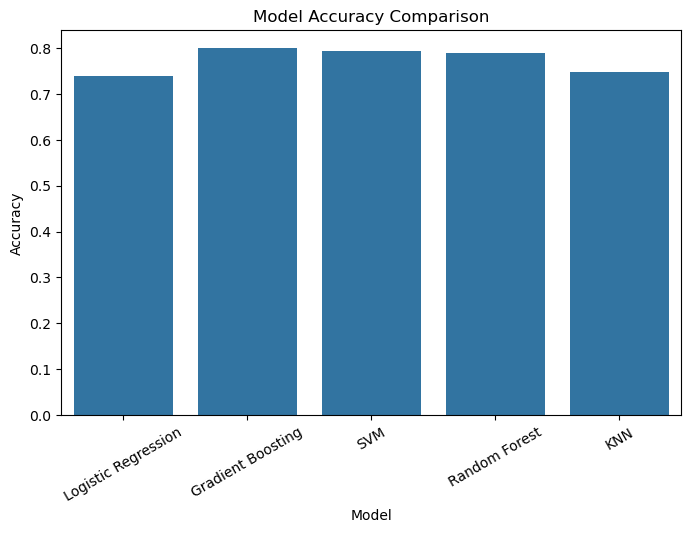

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

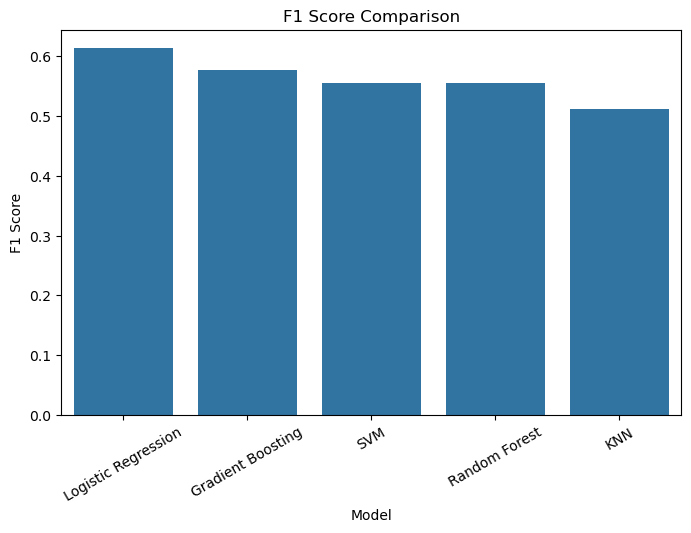

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.xticks(rotation=30)
plt.title("F1 Score Comparison")
plt.show()

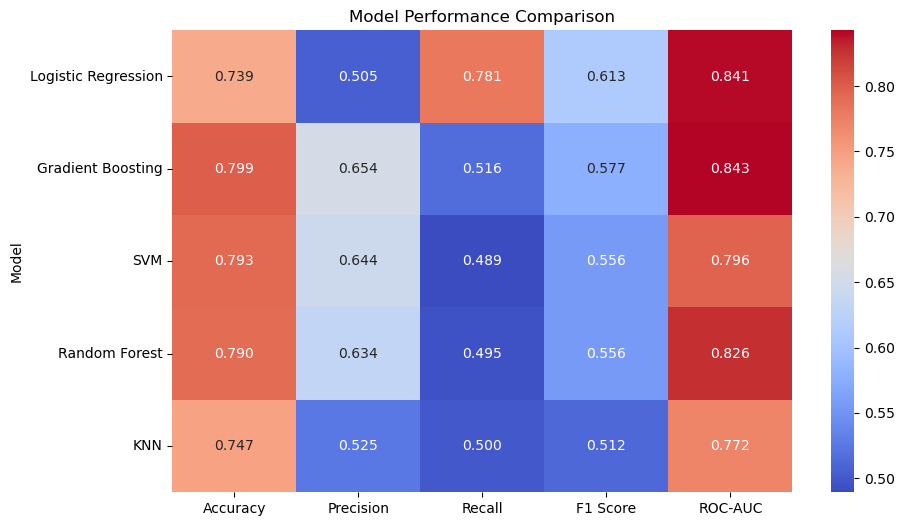

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(
    results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]],
    annot=True, fmt=".3f", cmap="coolwarm"
)
plt.title("Model Performance Comparison")
plt.show()